# Corrupted Image Dataset Generation

Downloads commercial-compatible Wikimedia Commons images, creates corrupted 224x224 samples, and writes strict 4-column labels.

In [19]:
import csv
from collections import Counter
import json
import random
import re
import time
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import requests
from IPython.display import display
from PIL import Image, ImageOps, UnidentifiedImageError
from tqdm.auto import tqdm

In [20]:
SEED = 42
TARGET_SAMPLES = 5_000
RAW_IMAGE_TARGET = 1_000
COMMONS_SEARCH_PAGES = 60
COMMONS_SEARCH_PAGE_SIZE = 50
DOWNLOAD_RETRIES = 4
DOWNLOAD_SLEEP_SECONDS = 0.4
IMAGE_SIZE = 224
MAX_SOURCE_PIXELS = 15_000_000

BRIGHTNESS_RANGE = (-0.5, 0.5)
CONTRAST_RANGE = (0.4, 2.2)
SATURATION_RANGE = (0.4, 2.2)
LABEL_FIELDS = ["image_id", "brightness", "contrast", "saturation"]

COMMONS_API = "https://commons.wikimedia.org/w/api.php"
USER_AGENT = "practice-image-enhancer-dataset/1.0 (local notebook; https://commons.wikimedia.org/)"
SEARCH_QUERIES = [
    "nature landscape",
    "city street",
    "food market",
    "people portrait",
    "vehicles transport",
    "animals wildlife",
    "architecture building",
    "objects still life",
    "mountains lake",
    "forest path",
    "beach ocean",
    "flowers garden",
    "interior room",
    "technology device",
    "sports event",
    "public domain photograph",
]

ROOT = Path.cwd()

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGE_DIR = PROCESSED_DIR / "images"
LABELS_CSV = PROCESSED_DIR / "labels.csv"
for directory in (RAW_DIR, IMAGE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

rng = random.Random(SEED)
session = requests.Session()
session.headers.update({"User-Agent": USER_AGENT})

print(f"Root: {ROOT}")
print(f"Output: {PROCESSED_DIR}")

Root: c:\Users\Марсель\Documents\practice\ml
Output: c:\Users\Марсель\Documents\practice\ml\data\processed


In [21]:
def clean_html(value):
    if not value:
        return ""
    return re.sub(r"<[^>]+>", "", str(value)).strip()


def ext_value(extmetadata, key):
    return clean_html(extmetadata.get(key, {}).get("value", ""))


def license_is_commercial_compatible(short_name, license_url):
    text = f"{short_name} {license_url}".lower()
    deny_patterns = [
        "noncommercial",
        "non-commercial",
        "no derivatives",
        "noderivatives",
        "fair use",
        "copyrighted free use",
    ]
    if any(pattern in text for pattern in deny_patterns):
        return False
    if re.search(r"(^|[^a-z])nc($|[^a-z])", text) or re.search(r"(^|[^a-z])nd($|[^a-z])", text):
        return False
    allow_patterns = ["public domain", "cc0", "cc by", "cc-by"]
    return any(pattern in text for pattern in allow_patterns)


def safe_stem(value):
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", value).strip("._-")
    return stem[:120] or "image"


def suffix_from_url(url, mime):
    suffix = Path(urlparse(url).path).suffix.lower()
    if suffix in {".jpg", ".jpeg", ".png", ".webp"}:
        return suffix
    return {"image/jpeg": ".jpg", "image/png": ".png", "image/webp": ".webp"}.get(mime, ".jpg")


def commons_request(params, retries=DOWNLOAD_RETRIES):
    last_error = None
    for attempt in range(retries):
        try:
            response = session.get(COMMONS_API, params=params, timeout=30)
            response.raise_for_status()
            return response.json()
        except (requests.RequestException, ValueError) as error:
            last_error = error
            time.sleep(DOWNLOAD_SLEEP_SECONDS * (2 ** attempt))
    raise RuntimeError(f"Commons API request failed after {retries} attempts: {last_error}")


def commons_search(query, search_counts, per_page=COMMONS_SEARCH_PAGE_SIZE, max_pages=COMMONS_SEARCH_PAGES):
    candidates = []
    continuation = {}
    for _ in range(max_pages):
        params = {
            "action": "query",
            "format": "json",
            "generator": "search",
            "gsrsearch": query,
            "gsrnamespace": 6,
            "gsrlimit": per_page,
            "prop": "imageinfo",
            "iiprop": "url|size|mime|extmetadata",
        }
        params.update(continuation)
        payload = commons_request(params)
        pages = payload.get("query", {}).get("pages", {})

        for page in pages.values():
            search_counts["seen"] += 1
            imageinfo = page.get("imageinfo") or []
            if not imageinfo:
                search_counts["missing_imageinfo"] += 1
                continue
            info = imageinfo[0]
            mime = info.get("mime", "")
            width = int(info.get("width") or 0)
            height = int(info.get("height") or 0)
            pixels = width * height
            if mime not in {"image/jpeg", "image/png", "image/webp"}:
                search_counts["unsupported_mime"] += 1
                continue
            if min(width, height) < IMAGE_SIZE:
                search_counts["too_small"] += 1
                continue
            if pixels > MAX_SOURCE_PIXELS:
                search_counts["too_large"] += 1
                continue

            extmetadata = info.get("extmetadata", {})
            license_name = ext_value(extmetadata, "LicenseShortName")
            license_url = ext_value(extmetadata, "LicenseUrl")
            if not license_is_commercial_compatible(license_name, license_url):
                search_counts["license_rejected"] += 1
                continue

            url = info.get("url")
            if not url:
                search_counts["missing_url"] += 1
                continue
            search_counts["candidate_ok"] += 1

            candidates.append({
                "pageid": page.get("pageid"),
                "title": page.get("title", ""),
                "url": url,
                "mime": mime,
                "width": width,
                "height": height,
                "pixels": pixels,
            })

        if "continue" not in payload:
            break
        continuation = payload["continue"]
        time.sleep(0.1)
    return candidates

In [22]:
def image_loads(path):
    try:
        with Image.open(path) as image:
            width, height = image.size
            if min(width, height) < IMAGE_SIZE:
                return False, "too_small"
            if width * height > MAX_SOURCE_PIXELS:
                return False, "too_large"
            image.load()
            return True, "ok"
    except (OSError, UnidentifiedImageError):
        return False, "bad_image"


def download_candidate(candidate, skip_counts):
    suffix = suffix_from_url(candidate["url"], candidate["mime"])
    name = f"{candidate['pageid']}_{safe_stem(candidate['title'])}{suffix}"
    path = RAW_DIR / name
    if path.exists():
        valid, reason = image_loads(path)
        if valid:
            return path
        path.unlink(missing_ok=True)
        skip_counts[reason] += 1

    last_error = None
    for attempt in range(DOWNLOAD_RETRIES):
        try:
            with session.get(candidate["url"], stream=True, timeout=90) as response:
                response.raise_for_status()
                with path.open("wb") as file:
                    for chunk in response.iter_content(chunk_size=1024 * 256):
                        if chunk:
                            file.write(chunk)
            valid, reason = image_loads(path)
            if valid:
                time.sleep(DOWNLOAD_SLEEP_SECONDS)
                return path
            path.unlink(missing_ok=True)
            skip_counts[reason] += 1
            return None
        except requests.RequestException as error:
            last_error = error
            path.unlink(missing_ok=True)
            time.sleep(DOWNLOAD_SLEEP_SECONDS * (2 ** attempt))
    skip_counts["request_failed"] += 1
    skip_counts[f"last_error:{type(last_error).__name__}"] += 1
    return None


def load_cached_sources():
    sources = []
    for raw_path in sorted(RAW_DIR.iterdir()):
        if not raw_path.is_file():
            continue
        valid, _ = image_loads(raw_path)
        if valid:
            sources.append({"raw_path": str(raw_path.relative_to(ROOT))})
    return sources


downloaded_sources = load_cached_sources()
seen_urls = set()
print(f"Cached usable sources: {len(downloaded_sources)}")

all_candidates = []
search_counts = Counter()
for query in SEARCH_QUERIES:
    print(f"Searching Commons: {query}")
    for candidate in commons_search(query, search_counts):
        if candidate["url"] in seen_urls:
            continue
        seen_urls.add(candidate["url"])
        all_candidates.append(candidate)
    if len(all_candidates) >= RAW_IMAGE_TARGET * 5:
        break

rng.shuffle(all_candidates)
skip_counts = Counter()
for candidate in tqdm(all_candidates, desc="Downloading raw images"):
    if len(downloaded_sources) >= RAW_IMAGE_TARGET:
        break
    path = download_candidate(candidate, skip_counts)
    if path is None:
        continue
    candidate = dict(candidate)
    candidate["raw_path"] = str(path.relative_to(ROOT))
    downloaded_sources.append(candidate)

print(f"Usable sources: {len(downloaded_sources)}")
print(f"Search counts: {dict(search_counts)}")
print(f"Skipped candidates: {dict(skip_counts)}")

Cached usable sources: 737
Searching Commons: nature landscape
Searching Commons: city street
Searching Commons: food market


Usable sources: 1000
Search counts: {'seen': 9000, 'candidate_ok': 6387, 'too_large': 2527, 'unsupported_mime': 64, 'license_rejected': 17, 'too_small': 5}
Skipped candidates: {}


In [25]:
def clean_preview(raw_path):
    with Image.open(raw_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        image.load()
        return ImageOps.fit(image, (IMAGE_SIZE, IMAGE_SIZE), method=RESAMPLE_LANCZOS, centering=(0.5, 0.5))


def make_corrupted_image(clean_image, brightness, contrast, saturation):
    clean = np.asarray(clean_image, dtype=np.float32)
    gray = clean[..., 0] * 0.2126 + clean[..., 1] * 0.7152 + clean[..., 2] * 0.0722
    before_saturation = gray[..., None] + (clean - gray[..., None]) / saturation
    corrupted = ((before_saturation - 128.0 - brightness * 255.0) / contrast) + 128.0
    corrupted = np.clip(corrupted, 0, 255).astype(np.uint8)
    return Image.fromarray(corrupted, mode="RGB")


def sample_target():
    return {
        "brightness": rng.uniform(*BRIGHTNESS_RANGE),
        "contrast": rng.uniform(*CONTRAST_RANGE),
        "saturation": rng.uniform(*SATURATION_RANGE),
    }


rows = []
generation_skips = Counter()
index = 0
progress = tqdm(total=TARGET_SAMPLES, desc="Generating corrupted samples")
while index < TARGET_SAMPLES:
    if not downloaded_sources:
        raise RuntimeError("No usable source images remain after validation.")
    source = rng.choice(downloaded_sources)
    raw_path = ROOT / source["raw_path"]
    image_id = f"sample_{index:06d}"
    target = sample_target()

    try:
        clean = clean_preview(raw_path)
    except (OSError, UnidentifiedImageError) as error:
        generation_skips[type(error).__name__] += 1
        downloaded_sources.remove(source)
        raw_path.unlink(missing_ok=True)
        continue
    corrupted = make_corrupted_image(clean, target["brightness"], target["contrast"], target["saturation"])
    corrupted.save(IMAGE_DIR / f"{image_id}.jpg", format="JPEG", quality=92, optimize=True)

    rows.append({
        "image_id": image_id,
        "brightness": f"{target['brightness']:.8f}",
        "contrast": f"{target['contrast']:.8f}",
        "saturation": f"{target['saturation']:.8f}",
    })
    index += 1
    progress.update(1)
progress.close()

with LABELS_CSV.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=LABEL_FIELDS, lineterminator="\n")
    writer.writeheader()
    writer.writerows(rows)

print(f"Generation skipped bad sources: {dict(generation_skips)}")
print(f"Saved images: {IMAGE_DIR}")
print(f"Saved labels: {LABELS_CSV}")

Generating corrupted samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Generation skipped bad sources: {'FileNotFoundError': 1}
Saved images: c:\Users\Марсель\Documents\practice\ml\data\processed\images
Saved labels: c:\Users\Марсель\Documents\practice\ml\data\processed\labels.csv


In [ ]:
with LABELS_CSV.open("r", newline="", encoding="utf-8") as file:
    reader = csv.DictReader(file)
    validation_rows = list(reader)
    assert reader.fieldnames == LABEL_FIELDS, reader.fieldnames

assert len(validation_rows) == TARGET_SAMPLES, len(validation_rows)

for row in tqdm(validation_rows, desc="Validating processed dataset"):
    image_path = IMAGE_DIR / f"{row['image_id']}.jpg"
    assert image_path.exists(), image_path
    brightness = float(row["brightness"])
    contrast = float(row["contrast"])
    saturation = float(row["saturation"])
    assert BRIGHTNESS_RANGE[0] <= brightness <= BRIGHTNESS_RANGE[1], row
    assert CONTRAST_RANGE[0] <= contrast <= CONTRAST_RANGE[1], row
    assert SATURATION_RANGE[0] <= saturation <= SATURATION_RANGE[1], row
    with Image.open(image_path) as image:
        assert image.mode == "RGB", (image_path, image.mode)
        assert image.size == (IMAGE_SIZE, IMAGE_SIZE), (image_path, image.size)

print("Dataset validation passed")

Validating processed dataset:   0%|          | 0/10000 [00:00<?, ?it/s]

Dataset validation passed


sample_000000 brightness=+0.497 contrast=0.724 saturation=1.782


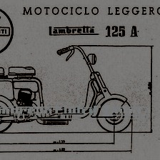

sample_000001 brightness=+0.453 contrast=1.231 saturation=1.675


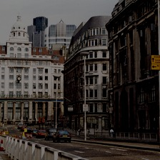

sample_000002 brightness=+0.298 contrast=1.896 saturation=0.524


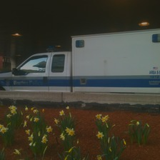

sample_000003 brightness=+0.296 contrast=1.136 saturation=1.299


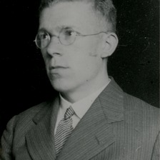

sample_000004 brightness=-0.197 contrast=0.855 saturation=0.677


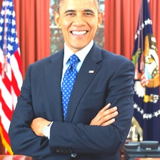

sample_000005 brightness=+0.289 contrast=0.533 saturation=2.183


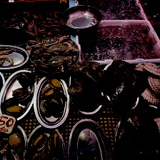

sample_000006 brightness=+0.082 contrast=1.362 saturation=2.062


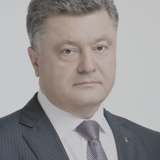

sample_000007 brightness=+0.192 contrast=1.379 saturation=1.823


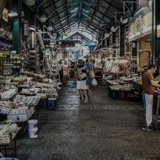

In [ ]:
preview_rows = validation_rows[:8]
for row in preview_rows:
    print(
        row["image_id"],
        f"brightness={float(row['brightness']):+.3f}",
        f"contrast={float(row['contrast']):.3f}",
        f"saturation={float(row['saturation']):.3f}",
    )
    display(Image.open(IMAGE_DIR / f"{row['image_id']}.jpg").resize((160, 160)))